# 04B - Modelado V2 local rapido

Notebook preparado para terminar entrenamiento hoy en PC local.

Objetivo: predecir `susceptibility` binaria:

- `Resistant`
- `Susceptible`

Este notebook usa la infraestructura del notebook de cluster, pero ajustada para tu maquina local:

- menos configuraciones por modelo
- menos paralelizacion para evitar saturar RAM/CPU
- solo modelos con mejor relacion rendimiento/tiempo
- salidas separadas en `05_RESULTADOS/local_rapido/` y `GRAFICAS/local_rapido/`

## Estrategia local

No conviene correr los 14 modelos masivos en tu PC si necesitas terminar hoy. La corrida larga anterior ya mostro que los mejores candidatos fueron:

- `random_forest`
- `hist_gradient_boosting`
- `xgboost`

Por eso esta corrida prueba modelos fuertes y relativamente razonables:

- `hist_gradient_boosting`
- `random_forest`
- `extra_trees`
- `xgboost`
- `logistic_regression`

Configuracion recomendada local:

- `N_JOBS_GRID = 4`
- `N_JOBS_MODELO = 1`
- `N_JOBS_XGBOOST = 4`
- `CONFIGURACIONES_POR_MODELO = 100`
- `REANUDAR = True`

Total aproximado: 5 modelos x 100 configs x 3 folds = 1500 fits internos.


In [1]:
# Esta celda debe ejecutarse antes de importar numpy/sklearn para controlar hilos nativos.
import os

MODO_EJECUCION = "local_rapido"
N_HILOS_CLUSTER = 6
N_JOBS_GRID = 4
N_JOBS_MODELO = 1
N_JOBS_XGBOOST = 4
CONFIGURACIONES_POR_MODELO = 100
REANUDAR = True
USAR_CUDA_XGBOOST = True
DATASET_USAR = "balanceado_organismo_clase"
RANDOM_STATE = 42

# Evita que BLAS/OpenMP use muchos hilos dentro de cada proceso de GridSearchCV.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

print("Configuracion de ejecucion")
print("MODO_EJECUCION:", MODO_EJECUCION)
print("N_JOBS_GRID:", N_JOBS_GRID)
print("N_JOBS_MODELO:", N_JOBS_MODELO)
print("N_JOBS_XGBOOST:", N_JOBS_XGBOOST)
print("CONFIGURACIONES_POR_MODELO:", CONFIGURACIONES_POR_MODELO)
print("REANUDAR:", REANUDAR)


Configuracion de ejecucion
MODO_EJECUCION: local_rapido
N_JOBS_GRID: 4
N_JOBS_MODELO: 1
N_JOBS_XGBOOST: 4
CONFIGURACIONES_POR_MODELO: 100
REANUDAR: True


In [2]:
from pathlib import Path
import json
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    mean_squared_error, mean_absolute_error, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, average_precision_score, log_loss,
    brier_score_loss, matthews_corrcoef, cohen_kappa_score, fbeta_score,
    roc_curve, precision_recall_curve, auc,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import ComplementNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
)
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")


## Como correr esto localmente

1. Abre este notebook en JupyterLab o VS Code.
2. Ejecuta todas las celdas desde arriba.
3. Si se corta, vuelve a ejecutar: con `REANUDAR = True` saltara modelos que ya tengan resultados completos.
4. Los resultados quedan en `modelo/V2/05_RESULTADOS/local_rapido/`.
5. Las graficas quedan en `modelo/V2/GRAFICAS/local_rapido/`.

Si tienes poco tiempo, puedes dejar solo:

```python
MODELOS_A_EJECUTAR = ["hist_gradient_boosting", "random_forest", "xgboost"]
```

Si quieres correr la version recomendada completa de hoy, deja los 5 modelos definidos en este notebook.


In [3]:
RUTA_ACTUAL = Path.cwd().resolve()
RUTA_MODELO = None
for candidata in [RUTA_ACTUAL, *RUTA_ACTUAL.parents]:
    if (candidata / "V2" / "DATOS_PROCESADOS").exists() and candidata.name.lower() == "modelo":
        RUTA_MODELO = candidata
        break
    if (candidata / "modelo" / "V2" / "DATOS_PROCESADOS").exists():
        RUTA_MODELO = candidata / "modelo"
        break
if RUTA_MODELO is None:
    raise FileNotFoundError("No se encontro modelo/V2/DATOS_PROCESADOS. Ejecuta primero notebooks 01-03 de V2.")

RUTA_V2 = RUTA_MODELO / "V2"
RUTA_PROCESADOS = RUTA_V2 / "DATOS_PROCESADOS"
RUTA_RESULTADOS = RUTA_V2 / "05_RESULTADOS"
RUTA_RESULTADOS_CLUSTER = RUTA_RESULTADOS / MODO_EJECUCION
RUTA_GRAFICAS = RUTA_V2 / "GRAFICAS"
RUTA_GRAFICAS_CLUSTER = RUTA_GRAFICAS / MODO_EJECUCION

RUTA_RESULTADOS_CLUSTER.mkdir(parents=True, exist_ok=True)
RUTA_GRAFICAS_CLUSTER.mkdir(parents=True, exist_ok=True)

rutas_dataset = {
    "completo": RUTA_PROCESADOS / "07_dataset_v2_multibacteria_completo.csv",
    "balanceado_clase": RUTA_PROCESADOS / "08_dataset_v2_multibacteria_balanceado_clase.csv",
    "balanceado_organismo_clase": RUTA_PROCESADOS / "09_dataset_v2_multibacteria_balanceado_organismo_clase.csv",
}
RUTA_DATASET = rutas_dataset[DATASET_USAR]
print("Dataset:", RUTA_DATASET)
print("Resultados ejecucion:", RUTA_RESULTADOS_CLUSTER)
print("Graficas ejecucion:", RUTA_GRAFICAS_CLUSTER)


Dataset: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\DATOS_PROCESADOS\09_dataset_v2_multibacteria_balanceado_organismo_clase.csv
Resultados ejecucion: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\05_RESULTADOS\local_rapido
Graficas ejecucion: D:\6TO-SEMESTRE\Sistemas Inteligentes\2doCorte\Proyecto\modelo\V2\GRAFICAS\local_rapido


In [4]:
df = pd.read_csv(RUTA_DATASET, low_memory=False)

ruta_decisiones = RUTA_PROCESADOS / "17_decision_variables_v2.csv"
if ruta_decisiones.exists():
    decisiones = pd.read_csv(ruta_decisiones)
    variables_excluidas = set(decisiones.loc[decisiones["decision"].eq("excluir"), "variable"])
else:
    variables_excluidas = set()

columnas_exp_prev = [c for c in df.columns if c.startswith("exp_prev_")]
if not columnas_exp_prev:
    raise ValueError("El dataset V2 no tiene columnas exp_prev_*. Ejecuta primero el notebook 02.")

columnas_excluir = {"anon_id", "pat_enc_csn_id_coded", "order_proc_id_coded", "order_time_jittered_utc", "susceptibility"}
columnas_excluir = columnas_excluir.union(variables_excluidas)

X = df.drop(columns=[c for c in columnas_excluir if c in df.columns])
y_texto = df["susceptibility"].astype(str)

le = LabelEncoder()
y = le.fit_transform(y_texto)

columnas_categoricas = X.select_dtypes(include=["object", "string"]).columns.tolist()
columnas_numericas = [c for c in X.columns if c not in columnas_categoricas]

print("Filas:", len(df))
print("Predictores:", X.shape[1])
print("Categoricas:", len(columnas_categoricas))
print("Numericas:", len(columnas_numericas))
print("Columnas exp_prev_*:", len(columnas_exp_prev))
print("Clases:", dict(zip(le.classes_, le.transform(le.classes_))))
display(y_texto.value_counts())


Filas: 242923
Predictores: 61
Categoricas: 6
Numericas: 55
Columnas exp_prev_*: 18
Clases: {'Resistant': np.int64(0), 'Susceptible': np.int64(1)}


susceptibility
Susceptible    150000
Resistant       92923
Name: count, dtype: int64

## Referencia: 3 mejores modelos del entrenamiento largo anterior

Estos resultados vienen de la corrida larga previa con 500 configuraciones totales. Sirven como linea base para comparar si la corrida rapida local mejora o no.


In [5]:
top_3_entrenamiento_largo = pd.DataFrame([
    {
        "ranking": 1,
        "modelo": "random_forest",
        "cv_f1_macro": 0.8359890948820722,
        "test_f1_macro": 0.8409881190147896,
        "test_balanced_accuracy": 0.8424206080172182,
        "test_mse": 0.15084902747761655,
        "mejores_parametros": '{"clf__max_depth": null, "clf__max_features": "sqrt", "clf__min_samples_leaf": 5, "clf__n_estimators": 400}',
    },
    {
        "ranking": 2,
        "modelo": "hist_gradient_boosting",
        "cv_f1_macro": 0.8369615140993029,
        "test_f1_macro": 0.8396571143295879,
        "test_balanced_accuracy": 0.8448757062146892,
        "test_mse": 0.15360708037460122,
        "mejores_parametros": '{"clf__l2_regularization": 2.0, "clf__learning_rate": 0.12, "clf__max_iter": 320, "clf__max_leaf_nodes": 95}',
    },
    {
        "ranking": 3,
        "modelo": "xgboost",
        "cv_f1_macro": 0.8300795232131758,
        "test_f1_macro": 0.8312890769820146,
        "test_balanced_accuracy": 0.8365752219531881,
        "test_mse": 0.16169599670680251,
        "mejores_parametros": '{"clf__colsample_bytree": 0.85, "clf__learning_rate": 0.12, "clf__max_depth": 6, "clf__min_child_weight": 3, "clf__n_estimators": 420, "clf__reg_lambda": 2.0, "clf__subsample": 0.8}',
    },
])

ruta_top3 = RUTA_RESULTADOS_CLUSTER / f"00_top3_entrenamiento_largo_referencia_{DATASET_USAR}.csv"
top_3_entrenamiento_largo.to_csv(ruta_top3, index=False)
display(top_3_entrenamiento_largo)


,ranking,modelo,cv_f1_macro,test_f1_macro,test_balanced_accuracy,test_mse,mejores_parametros
0,1,random_forest,0.835989,0.840988,0.842421,0.150849,"{""clf__max_depth"": null, ""clf__max_features"": ..."
1,2,hist_gradient_boosting,0.836962,0.839657,0.844876,0.153607,"{""clf__l2_regularization"": 2.0, ""clf__learning..."
2,3,xgboost,0.830080,0.831289,0.836575,0.161696,"{""clf__colsample_bytree"": 0.85, ""clf__learning..."


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocesador_escalado = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), columnas_numericas),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="SIN_REGISTRO")), ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]), columnas_categoricas),
])

preprocesador_minmax = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), columnas_numericas),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="SIN_REGISTRO")), ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]), columnas_categoricas),
])

preprocesador_arboles = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), columnas_numericas),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="SIN_REGISTRO")), ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]), columnas_categoricas),
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
pesos_train = compute_sample_weight(class_weight="balanced", y=y_train)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (194338, 61) Test: (48585, 61)


In [7]:
def seleccionar_configuraciones_uniformes(configuraciones, n=CONFIGURACIONES_POR_MODELO):
    """Selecciona configuraciones repartidas por toda la grilla, no solo las primeras."""
    if len(configuraciones) < n:
        raise ValueError(f"Cada modelo debe tener al menos {n} configuraciones, recibio {len(configuraciones)}")
    if len(configuraciones) == n:
        return configuraciones
    indices = np.linspace(0, len(configuraciones) - 1, n, dtype=int)
    return [configuraciones[i] for i in indices]


def construir_grid(configuraciones, esperado=CONFIGURACIONES_POR_MODELO):
    configuraciones = seleccionar_configuraciones_uniformes(configuraciones, esperado)
    return [{k: [v] for k, v in config.items()} for config in configuraciones]


In [8]:
# Grillas amplias. Cada familia queda reducida a CONFIGURACIONES_POR_MODELO puntos uniformemente distribuidos.
config_lr = []
for C in np.geomspace(0.003, 100.0, 50):
    config_lr.append({"clf__C": C, "clf__fit_intercept": True, "clf__solver": "lbfgs", "clf__penalty": "l2", "clf__tol": 1e-4})
    config_lr.append({"clf__C": C, "clf__fit_intercept": False, "clf__solver": "lbfgs", "clf__penalty": "l2", "clf__tol": 1e-4})
    for l1_ratio in [0.15, 0.50, 0.85]:
        config_lr.append({"clf__C": C, "clf__fit_intercept": True, "clf__solver": "saga", "clf__penalty": "elasticnet", "clf__l1_ratio": l1_ratio, "clf__tol": 1e-3})

config_svm_linear = [
    {"clf__C": C, "clf__tol": tol, "clf__loss": loss, "clf__class_weight": class_weight, "clf__max_iter": 6000}
    for C in np.geomspace(0.005, 30.0, 25)
    for tol in [1e-4, 5e-4]
    for loss in ["hinge", "squared_hinge"]
    for class_weight in ["balanced", None]
]

config_sgd = [
    {"clf__loss": loss, "clf__alpha": alpha, "clf__penalty": penalty, "clf__l1_ratio": l1_ratio, "clf__class_weight": "balanced", "clf__max_iter": 2500, "clf__tol": 1e-3}
    for loss in ["log_loss", "modified_huber", "hinge"]
    for alpha in np.geomspace(1e-6, 1e-2, 20)
    for penalty in ["l2", "elasticnet"]
    for l1_ratio in [0.15, 0.50]
]

config_knn = [
    {"svd__n_components": n_comp, "clf__n_neighbors": k, "clf__weights": weights, "clf__p": p}
    for n_comp in [30, 50, 80, 120, 160]
    for k in [3, 5, 7, 11, 15, 21, 31, 45, 61, 81]
    for weights in ["uniform", "distance"]
    for p in [1, 2]
]

config_cnb = [
    {"clf__alpha": alpha, "clf__fit_prior": fit_prior, "clf__norm": norm}
    for alpha in np.geomspace(1e-4, 100.0, 50)
    for fit_prior in [True, False]
    for norm in [True, False]
]

config_gnb = [
    {"svd__n_components": n_comp, "clf__var_smoothing": var_smoothing}
    for n_comp in [30, 50, 80, 120]
    for var_smoothing in np.geomspace(1e-12, 1e-2, 50)
]

config_dt = [
    {"clf__max_depth": max_depth, "clf__min_samples_leaf": min_leaf, "clf__criterion": criterion, "clf__ccp_alpha": ccp_alpha, "clf__min_samples_split": min_split}
    for max_depth in [4, 6, 8, 10, 12, 16, 20, 28, None]
    for min_leaf in [5, 10, 20, 40, 80, 120]
    for min_split in [2, 10]
    for criterion in ["gini", "entropy", "log_loss"]
    for ccp_alpha in [0.0, 0.0002, 0.001]
]

config_rf = [
    {"clf__n_estimators": n_estimators, "clf__max_depth": max_depth, "clf__min_samples_leaf": min_leaf, "clf__max_features": max_features, "clf__bootstrap": bootstrap}
    for n_estimators in [160, 240, 320, 420, 560]
    for max_depth in [12, 18, 24, None]
    for min_leaf in [2, 5, 10, 20, 40]
    for max_features in ["sqrt", "log2"]
    for bootstrap in [True, False]
]

config_extra_trees = [
    {"clf__n_estimators": n_estimators, "clf__max_depth": max_depth, "clf__min_samples_leaf": min_leaf, "clf__max_features": max_features, "clf__bootstrap": bootstrap}
    for n_estimators in [160, 240, 320, 420, 560]
    for max_depth in [12, 18, 24, None]
    for min_leaf in [2, 5, 10, 20, 40]
    for max_features in ["sqrt", "log2"]
    for bootstrap in [False, True]
]

config_adaboost = [
    {"clf__n_estimators": n_estimators, "clf__learning_rate": learning_rate, "clf__estimator__max_depth": depth, "clf__estimator__min_samples_leaf": min_leaf}
    for n_estimators in [80, 120, 180, 240, 320]
    for learning_rate in [0.01, 0.03, 0.05, 0.08, 0.12]
    for depth in [1, 2, 3, 4]
    for min_leaf in [10, 30, 60, 100]
]

config_gb = [
    {"clf__n_estimators": n_estimators, "clf__learning_rate": learning_rate, "clf__max_depth": depth, "clf__min_samples_leaf": min_leaf, "clf__subsample": subsample}
    for n_estimators in [80, 120, 180, 240]
    for learning_rate in [0.02, 0.04, 0.06, 0.10, 0.15]
    for depth in [2, 3, 4, 5]
    for min_leaf in [10, 30, 60]
    for subsample in [0.75, 0.90, 1.0]
]

config_hgb = [
    {"clf__max_iter": max_iter, "clf__learning_rate": learning_rate, "clf__max_leaf_nodes": max_leaf_nodes, "clf__l2_regularization": l2, "clf__min_samples_leaf": min_leaf}
    for max_iter in [120, 180, 240, 320, 440]
    for learning_rate in [0.02, 0.03, 0.05, 0.08, 0.12]
    for max_leaf_nodes in [15, 31, 63, 95]
    for l2 in [0.0, 0.1, 1.0, 2.0]
    for min_leaf in [20, 40]
]

config_mlp = [
    {"svd__n_components": n_comp, "clf__hidden_layer_sizes": hidden, "clf__alpha": alpha, "clf__learning_rate_init": lr, "clf__activation": activation}
    for n_comp in [50, 80, 120, 160]
    for hidden in [(32,), (64,), (96,), (64, 32), (128, 64)]
    for alpha in [1e-5, 1e-4, 1e-3, 1e-2]
    for lr in [0.0005, 0.001, 0.003]
    for activation in ["relu", "tanh"]
]

config_xgb = [
    {
        "clf__n_estimators": n_estimators,
        "clf__max_depth": max_depth,
        "clf__learning_rate": learning_rate,
        "clf__subsample": subsample,
        "clf__colsample_bytree": colsample,
        "clf__min_child_weight": min_child_weight,
        "clf__reg_lambda": reg_lambda,
        "clf__reg_alpha": reg_alpha,
    }
    for n_estimators in [160, 240, 320, 440, 600]
    for max_depth in [3, 4, 5, 6, 8]
    for learning_rate in [0.02, 0.03, 0.05, 0.08, 0.12]
    for subsample in [0.75, 0.85, 0.95]
    for colsample in [0.75, 0.85, 0.95]
    for min_child_weight in [1, 3, 5]
    for reg_lambda in [1.0, 2.0, 5.0]
    for reg_alpha in [0.0, 0.1]
]


In [9]:
modelos_parametros = {
    "logistic_regression": (
        Pipeline([("prep", preprocesador_escalado), ("clf", LogisticRegression(max_iter=2500, class_weight="balanced", n_jobs=N_JOBS_MODELO, random_state=RANDOM_STATE))]),
        construir_grid(config_lr),
    ),
    "svm_linear": (
        Pipeline([("prep", preprocesador_escalado), ("clf", LinearSVC(random_state=RANDOM_STATE, dual="auto"))]),
        construir_grid(config_svm_linear),
    ),
    "sgd_linear": (
        Pipeline([("prep", preprocesador_escalado), ("clf", SGDClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS_MODELO))]),
        construir_grid(config_sgd),
    ),
    "knn_svd": (
        Pipeline([("prep", preprocesador_escalado), ("svd", TruncatedSVD(random_state=RANDOM_STATE)), ("clf", KNeighborsClassifier(algorithm="brute", n_jobs=N_JOBS_MODELO))]),
        construir_grid(config_knn),
    ),
    "complement_naive_bayes": (
        Pipeline([("prep", preprocesador_minmax), ("clf", ComplementNB())]),
        construir_grid(config_cnb),
    ),
    "gaussian_naive_bayes_svd": (
        Pipeline([("prep", preprocesador_escalado), ("svd", TruncatedSVD(random_state=RANDOM_STATE)), ("clf", GaussianNB())]),
        construir_grid(config_gnb),
    ),
    "decision_tree": (
        Pipeline([("prep", preprocesador_arboles), ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
        construir_grid(config_dt),
    ),
    "random_forest": (
        Pipeline([("prep", preprocesador_arboles), ("clf", RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=N_JOBS_MODELO))]),
        construir_grid(config_rf),
    ),
    "extra_trees": (
        Pipeline([("prep", preprocesador_arboles), ("clf", ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=N_JOBS_MODELO))]),
        construir_grid(config_extra_trees),
    ),
    "adaboost_tree": (
        Pipeline([("prep", preprocesador_arboles), ("clf", AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), random_state=RANDOM_STATE))]),
        construir_grid(config_adaboost),
    ),
    "gradient_boosting": (
        Pipeline([("prep", preprocesador_arboles), ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
        construir_grid(config_gb),
    ),
    "hist_gradient_boosting": (
        Pipeline([("prep", preprocesador_arboles), ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight="balanced"))]),
        construir_grid(config_hgb),
    ),
    "mlp_svd": (
        Pipeline([("prep", preprocesador_escalado), ("svd", TruncatedSVD(random_state=RANDOM_STATE)), ("clf", MLPClassifier(max_iter=120, early_stopping=True, random_state=RANDOM_STATE))]),
        construir_grid(config_mlp),
    ),
    "xgboost": (
        Pipeline([("prep", preprocesador_arboles), ("clf", XGBClassifier(
            objective="binary:logistic", eval_metric="logloss", tree_method="hist",
            device="cuda" if USAR_CUDA_XGBOOST else "cpu", random_state=RANDOM_STATE, n_jobs=N_JOBS_XGBOOST,
        ))]),
        construir_grid(config_xgb),
    ),
}

resumen_configuraciones = pd.DataFrame([
    {"modelo": nombre, "configuraciones": len(param_grid), "fits_cv_estimados": len(param_grid) * cv.get_n_splits()}
    for nombre, (_, param_grid) in modelos_parametros.items()
])
resumen_configuraciones.to_csv(RUTA_RESULTADOS_CLUSTER / f"00_configuraciones_local_rapido_v2_binario_{DATASET_USAR}.csv", index=False)
display(resumen_configuraciones)
print("Total configuraciones:", int(resumen_configuraciones["configuraciones"].sum()))
print("Total fits CV estimados:", int(resumen_configuraciones["fits_cv_estimados"].sum()))


,modelo,configuraciones,fits_cv_estimados
0,logistic_regression,100,300
1,svm_linear,100,300
2,sgd_linear,100,300
3,knn_svd,100,300
4,complement_naive_bayes,100,300
5,gaussian_naive_bayes_svd,100,300
6,decision_tree,100,300
7,random_forest,100,300
8,extra_trees,100,300
9,adaboost_tree,100,300


Total configuraciones: 1400
Total fits CV estimados: 4200


## Seleccion de modelos a correr

Esta corrida local esta enfocada para terminar hoy. Por defecto corre 5 modelos:

```python
MODELOS_A_EJECUTAR = [
    "hist_gradient_boosting",
    "random_forest",
    "extra_trees",
    "xgboost",
    "logistic_regression",
]
```

Si necesitas recortar mas tiempo, deja solo:

```python
MODELOS_A_EJECUTAR = ["hist_gradient_boosting", "random_forest", "xgboost"]
```


In [10]:
MODELOS_A_EJECUTAR = [
    "hist_gradient_boosting",
    "random_forest",
    "extra_trees",
    "xgboost",
    "logistic_regression",
]
MODELOS_A_EJECUTAR


['hist_gradient_boosting',
 'random_forest',
 'extra_trees',
 'xgboost',
 'logistic_regression']

In [11]:

def obtener_proba_resistant(modelo, X_eval, indice_resistant):
    """Devuelve probabilidad de Resistant si el modelo la soporta."""
    if not hasattr(modelo, "predict_proba"):
        return None
    try:
        proba = modelo.predict_proba(X_eval)
        clases_modelo = modelo.named_steps["clf"].classes_ if hasattr(modelo, "named_steps") else modelo.classes_
        pos = int(np.where(clases_modelo == indice_resistant)[0][0])
        return proba[:, pos]
    except Exception:
        return None


def entrenar_modelo_cluster(nombre, pipeline, params):
    ruta_cv = RUTA_RESULTADOS_CLUSTER / f"cv_detalle_{nombre}_local_rapido_v2_binario_{DATASET_USAR}.csv"
    ruta_resumen = RUTA_RESULTADOS_CLUSTER / f"resultado_{nombre}_local_rapido_v2_binario_{DATASET_USAR}.csv"
    ruta_reporte = RUTA_RESULTADOS_CLUSTER / f"reporte_{nombre}_local_rapido_v2_binario_{DATASET_USAR}.json"

    if REANUDAR and ruta_cv.exists() and ruta_resumen.exists() and ruta_reporte.exists():
        print(f"Saltando {nombre}: resultados existentes")
        return pd.read_csv(ruta_resumen), pd.read_csv(ruta_cv)

    print(f"\n=== Entrenando {nombre} ===")
    inicio = time.time()
    busqueda = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        scoring="f1_macro",
        cv=cv,
        n_jobs=N_JOBS_GRID if nombre != "xgboost" else 1,
        verbose=2,
        error_score="raise",
        return_train_score=True,
    )

    try:
        if nombre == "xgboost":
            busqueda.fit(X_train, y_train, clf__sample_weight=pesos_train)
        else:
            busqueda.fit(X_train, y_train)
    except Exception as error:
        if nombre == "xgboost" and USAR_CUDA_XGBOOST:
            print("XGBoost CUDA fallo, reintentando en CPU:", error)
            pipeline.set_params(clf__device="cpu")
            busqueda = GridSearchCV(
                estimator=pipeline,
                param_grid=params,
                scoring="f1_macro",
                cv=cv,
                n_jobs=1,
                verbose=2,
                error_score="raise",
                return_train_score=True,
            )
            busqueda.fit(X_train, y_train, clf__sample_weight=pesos_train)
        else:
            raise

    tiempo_min = (time.time() - inicio) / 60
    mejor = busqueda.best_estimator_
    pred = mejor.predict(X_test)

    indice_resistant = int(np.where(le.classes_ == "Resistant")[0][0])
    y_bin = (np.asarray(y_test) == indice_resistant).astype(int)
    pred_bin = (np.asarray(pred) == indice_resistant).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_bin, pred_bin, labels=[0, 1]).ravel()
    sensibilidad_resistant = tp / (tp + fn) if (tp + fn) else np.nan
    especificidad_resistant = tn / (tn + fp) if (tn + fp) else np.nan
    ppv_resistant = tp / (tp + fp) if (tp + fp) else np.nan
    npv_resistant = tn / (tn + fn) if (tn + fn) else np.nan

    proba_resistant = obtener_proba_resistant(mejor, X_test, indice_resistant)
    if proba_resistant is not None:
        eps = 1e-15
        proba_clip = np.clip(proba_resistant, eps, 1 - eps)
        roc_auc = roc_auc_score(y_bin, proba_resistant)
        pr_auc = average_precision_score(y_bin, proba_resistant)
        logloss = log_loss(y_bin, proba_clip, labels=[0, 1])
        brier = brier_score_loss(y_bin, proba_resistant)
    else:
        roc_auc = np.nan
        pr_auc = np.nan
        logloss = np.nan
        brier = np.nan

    fila = {
        "dataset": DATASET_USAR,
        "modelo": nombre,
        "configuraciones_probadas": len(params),
        "fits_cv_estimados": len(params) * cv.get_n_splits(),
        "tiempo_minutos": tiempo_min,
        "cv_f1_macro": busqueda.best_score_,
        "test_accuracy": accuracy_score(y_test, pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "test_f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "test_f1_weighted": f1_score(y_test, pred, average="weighted", zero_division=0),
        "test_precision_macro": precision_score(y_test, pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test, pred, average="macro", zero_division=0),
        "test_sensibilidad_resistant": sensibilidad_resistant,
        "test_especificidad_resistant": especificidad_resistant,
        "test_ppv_resistant": ppv_resistant,
        "test_npv_resistant": npv_resistant,
        "test_mcc": matthews_corrcoef(y_test, pred),
        "test_cohen_kappa": cohen_kappa_score(y_test, pred),
        "test_mse": mean_squared_error(y_test, pred),
        "test_mae": mean_absolute_error(y_test, pred),
        "test_roc_auc_resistant": roc_auc,
        "test_pr_auc_resistant": pr_auc,
        "test_log_loss_resistant": logloss,
        "test_brier_score_resistant": brier,
        "tn_susceptible_correcto": tn,
        "fp_resistant_falso": fp,
        "fn_resistant_no_detectado": fn,
        "tp_resistant_correcto": tp,
        "mejores_parametros": json.dumps(busqueda.best_params_, ensure_ascii=False),
    }

    df_resumen = pd.DataFrame([fila])
    df_cv = pd.DataFrame(busqueda.cv_results_)
    df_cv["modelo"] = nombre
    df_cv["dataset"] = DATASET_USAR
    df_cv["gap_train_test"] = df_cv["mean_train_score"] - df_cv["mean_test_score"]

    reporte = classification_report(y_test, pred, target_names=le.classes_, output_dict=True, zero_division=0)

    df_cv.to_csv(ruta_cv, index=False)
    df_resumen.to_csv(ruta_resumen, index=False)
    with ruta_reporte.open("w", encoding="utf-8") as f:
        json.dump(reporte, f, ensure_ascii=False, indent=2)

    print(f"Terminado {nombre} en {tiempo_min:.1f} min")
    display(df_resumen)
    return df_resumen, df_cv


In [12]:
resultados = []
cv_detallado = []

for nombre in MODELOS_A_EJECUTAR:
    pipeline, params = modelos_parametros[nombre]
    df_resumen, df_cv = entrenar_modelo_cluster(nombre, pipeline, params)
    resultados.append(df_resumen)
    cv_detallado.append(df_cv)

resultados_df = pd.concat(resultados, ignore_index=True).sort_values("test_f1_macro", ascending=False)
cv_detallado_df = pd.concat(cv_detallado, ignore_index=True)

resultados_df.to_csv(RUTA_RESULTADOS_CLUSTER / f"01_resultados_modelos_local_rapido_v2_binario_{DATASET_USAR}.csv", index=False)
cv_detallado_df.to_csv(RUTA_RESULTADOS_CLUSTER / f"05_cv_detalle_todos_modelos_local_rapido_v2_binario_{DATASET_USAR}.csv", index=False)

display(resultados_df)



=== Entrenando hist_gradient_boosting ===
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Terminado hist_gradient_boosting en 70.0 min


,dataset,modelo,configuraciones_probadas,fits_cv_estimados,tiempo_minutos,cv_f1_macro,test_accuracy,test_balanced_accuracy,test_f1_macro,test_f1_weighted,...,test_mae,test_roc_auc_resistant,test_pr_auc_resistant,test_log_loss_resistant,test_brier_score_resistant,tn_susceptible_correcto,fp_resistant_falso,fn_resistant_no_detectado,tp_resistant_correcto,mejores_parametros
0,balanceado_organismo_clase,hist_gradient_boosting,100,300,70.047848,0.838508,0.849954,0.848824,0.843422,0.850936,...,0.150046,0.928252,0.891647,0.338828,0.107283,25609,4391,2899,15686,"{""clf__l2_regularization"": 2.0, ""clf__learning..."



=== Entrenando random_forest ===
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Terminado random_forest en 176.6 min


,dataset,modelo,configuraciones_probadas,fits_cv_estimados,tiempo_minutos,cv_f1_macro,test_accuracy,test_balanced_accuracy,test_f1_macro,test_f1_weighted,...,test_mae,test_roc_auc_resistant,test_pr_auc_resistant,test_log_loss_resistant,test_brier_score_resistant,tn_susceptible_correcto,fp_resistant_falso,fn_resistant_no_detectado,tp_resistant_correcto,mejores_parametros
0,balanceado_organismo_clase,random_forest,100,300,176.590424,0.850389,0.862982,0.856487,0.855408,0.863183,...,0.137018,0.935382,0.897871,0.330407,0.101702,26524,3476,3181,15404,"{""clf__bootstrap"": false, ""clf__max_depth"": nu..."



=== Entrenando extra_trees ===
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Terminado extra_trees en 181.8 min


...


=== Entrenando xgboost ===
Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END clf__colsample_bytree=0.75, clf__learning_rate=0.02, clf__max_depth=3, clf__min_child_weight=1, clf__n_estimators=160, clf__reg_alpha=0.0, clf__reg_lambda=1.0, clf__subsample=0.75; total time=   3.3s
[CV] END clf__colsample_bytree=0.75, clf__learning_rate=0.02, clf__max_depth=3, clf__min_child_weight=1, clf__n_estimators=160, clf__reg_alpha=0.0, clf__reg_lambda=1.0, clf__subsample=0.75; total time=   2.8s
[CV] END clf__colsample_bytree=0.75, clf__learning_rate=0.02, clf__max_depth=3, clf__min_child_weight=1, clf__n_estimators=160, clf__reg_alpha=0.0, clf__reg_lambda=1.0, clf__subsample=0.75; total time=   2.9s
[CV] END clf__colsample_bytree=0.95, clf__learning_rate=0.03, clf__max_depth=3, clf__min_child_weight=3, clf__n_estimators=160, clf__reg_alpha=0.0, clf__reg_lambda=1.0, clf__subsample=0.75; total time=   2.9s
[CV] END clf__colsample_bytree=0.95, clf__learning_rate=0.03, clf__max_de

,dataset,modelo,configuraciones_probadas,fits_cv_estimados,tiempo_minutos,cv_f1_macro,test_accuracy,test_balanced_accuracy,test_f1_macro,test_f1_weighted,...,test_mae,test_roc_auc_resistant,test_pr_auc_resistant,test_log_loss_resistant,test_brier_score_resistant,tn_susceptible_correcto,fp_resistant_falso,fn_resistant_no_detectado,tp_resistant_correcto,mejores_parametros
0,balanceado_organismo_clase,xgboost,100,300,26.774762,0.843197,0.853226,0.851842,0.84672,0.85414,...,0.146774,0.9303,0.894395,0.334974,0.105655,25732,4268,2863,15722,"{""clf__colsample_bytree"": 0.95, ""clf__learning..."



=== Entrenando logistic_regression ===
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Terminado logistic_regression en 26.6 min


,dataset,modelo,configuraciones_probadas,fits_cv_estimados,tiempo_minutos,cv_f1_macro,test_accuracy,test_balanced_accuracy,test_f1_macro,test_f1_weighted,...,test_mae,test_roc_auc_resistant,test_pr_auc_resistant,test_log_loss_resistant,test_brier_score_resistant,tn_susceptible_correcto,fp_resistant_falso,fn_resistant_no_detectado,tp_resistant_correcto,mejores_parametros
0,balanceado_organismo_clase,logistic_regression,100,300,26.550659,0.75674,0.765936,0.769632,0.759378,0.768711,...,0.234064,0.837659,0.730244,0.501856,0.165034,22617,7383,3989,14596,"{""clf__C"": 0.3219596952967591, ""clf__fit_inter..."


,dataset,modelo,configuraciones_probadas,fits_cv_estimados,tiempo_minutos,cv_f1_macro,test_accuracy,test_balanced_accuracy,test_f1_macro,test_f1_weighted,...,test_mae,test_roc_auc_resistant,test_pr_auc_resistant,test_log_loss_resistant,test_brier_score_resistant,tn_susceptible_correcto,fp_resistant_falso,fn_resistant_no_detectado,tp_resistant_correcto,mejores_parametros
1,balanceado_organismo_clase,random_forest,100,300,176.590424,0.850389,0.862982,0.856487,0.855408,0.863183,...,0.137018,0.935382,0.897871,0.330407,0.101702,26524,3476,3181,15404,"{""clf__bootstrap"": false, ""clf__max_depth"": nu..."
3,balanceado_organismo_clase,xgboost,100,300,26.774762,0.843197,0.853226,0.851842,0.846720,0.854140,...,0.146774,0.930300,0.894395,0.334974,0.105655,25732,4268,2863,15722,"{""clf__colsample_bytree"": 0.95, ""clf__learning..."
2,balanceado_organismo_clase,extra_trees,100,300,181.795423,0.842752,0.853720,0.848291,0.846108,0.854149,...,0.146280,0.930123,0.892550,0.341047,0.106098,26142,3858,3249,15336,"{""clf__bootstrap"": false, ""clf__max_depth"": nu..."
0,balanceado_organismo_clase,hist_gradient_boosting,100,300,70.047848,0.838508,0.849954,0.848824,0.843422,0.850936,...,0.150046,0.928252,0.891647,0.338828,0.107283,25609,4391,2899,15686,"{""clf__l2_regularization"": 2.0, ""clf__learning..."
4,balanceado_organismo_clase,logistic_regression,100,300,26.550659,0.756740,0.765936,0.769632,0.759378,0.768711,...,0.234064,0.837659,0.730244,0.501856,0.165034,22617,7383,3989,14596,"{""clf__C"": 0.3219596952967591, ""clf__fit_inter..."


In [13]:
indice_resistant = int(np.where(le.classes_ == "Resistant")[0][0])
indice_susceptible = int(np.where(le.classes_ == "Susceptible")[0][0])

# Para no reentrenar, esta seccion calcula diagnostico desde los CSV de CV ya generados.
mejores_cv_por_modelo = (
    cv_detallado_df.sort_values(["modelo", "mean_test_score"], ascending=[True, False])
    .groupby("modelo", as_index=False)
    .head(1)
    [["modelo", "mean_test_score", "std_test_score", "mean_train_score", "gap_train_test", "params"]]
    .sort_values("mean_test_score", ascending=False)
)
mejores_cv_por_modelo["riesgo_overfitting"] = pd.cut(
    mejores_cv_por_modelo["gap_train_test"],
    bins=[-np.inf, 0.03, 0.07, np.inf],
    labels=["bajo", "moderado", "alto"],
)
mejores_cv_por_modelo.to_csv(RUTA_RESULTADOS_CLUSTER / f"08_diagnostico_overfitting_cv_local_rapido_v2_binario_{DATASET_USAR}.csv", index=False)
display(mejores_cv_por_modelo)


,modelo,mean_test_score,std_test_score,mean_train_score,gap_train_test,params,riesgo_overfitting
155,random_forest,0.850389,0.001948,0.977312,0.126923,"{'clf__bootstrap': False, 'clf__max_depth': No...",alto
399,xgboost,0.843197,0.001504,0.897931,0.054734,"{'clf__colsample_bytree': 0.95, 'clf__learning...",moderado
215,extra_trees,0.842752,0.001683,0.952955,0.110204,"{'clf__bootstrap': False, 'clf__max_depth': No...",alto
99,hist_gradient_boosting,0.838508,0.000907,0.890976,0.052467,"{'clf__l2_regularization': 2.0, 'clf__learning...",moderado
444,logistic_regression,0.756740,0.001403,0.756820,0.000080,"{'clf__C': 0.3219596952967591, 'clf__fit_inter...",bajo


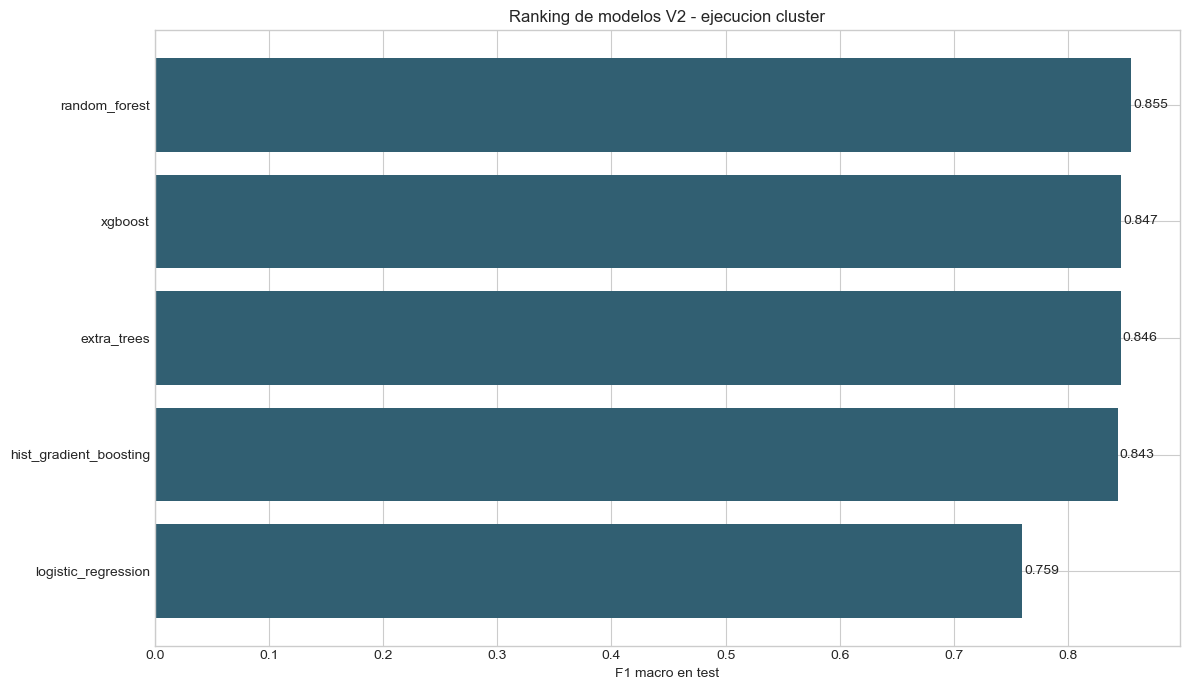

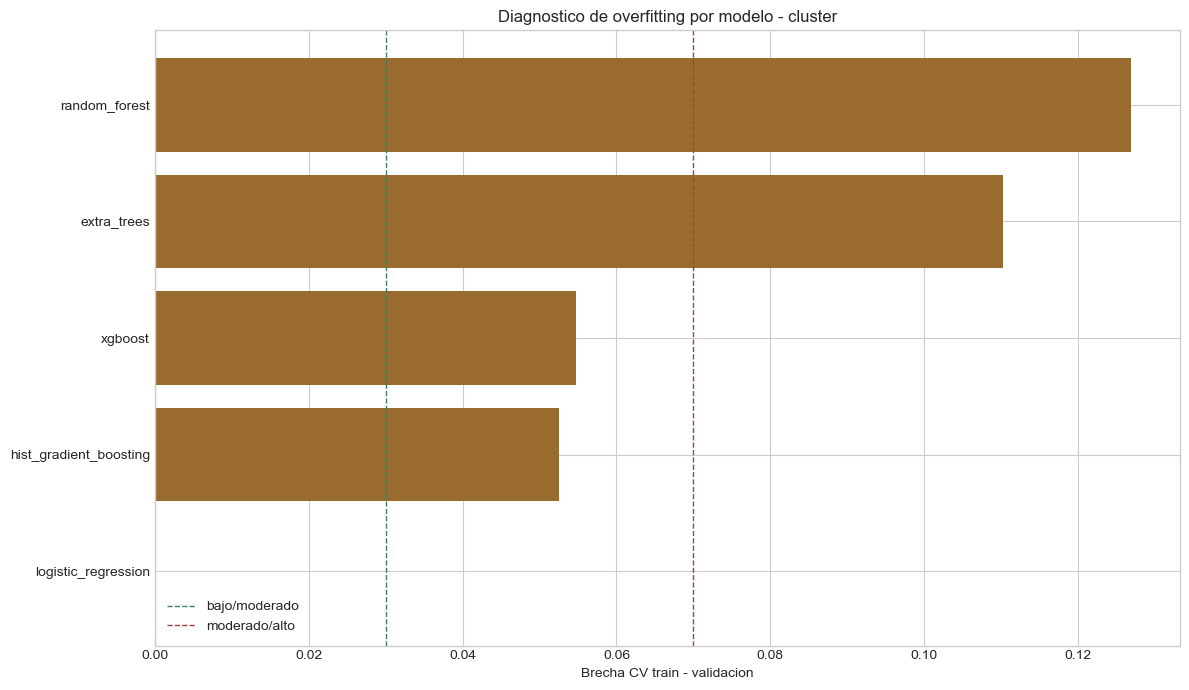

In [14]:
# Graficas resumen de cluster.
fig, ax = plt.subplots(figsize=(12, 7))
plot_df = resultados_df.sort_values("test_f1_macro", ascending=True)
ax.barh(plot_df["modelo"], plot_df["test_f1_macro"], color="#315f72")
ax.set_xlabel("F1 macro en test")
ax.set_title("Ranking de modelos V2 - ejecucion cluster")
for i, valor in enumerate(plot_df["test_f1_macro"]):
    ax.text(valor + 0.002, i, f"{valor:.3f}", va="center")
fig.tight_layout()
fig.savefig(RUTA_GRAFICAS_CLUSTER / f"01_local_rapido_ranking_modelos_v2_binario_{DATASET_USAR}.png", dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))
gap_plot = mejores_cv_por_modelo.sort_values("gap_train_test", ascending=True)
ax.barh(gap_plot["modelo"], gap_plot["gap_train_test"], color="#9a6b2f")
ax.axvline(0.03, color="#3f7d5c", linestyle="--", linewidth=1, label="bajo/moderado")
ax.axvline(0.07, color="#a33f3f", linestyle="--", linewidth=1, label="moderado/alto")
ax.set_xlabel("Brecha CV train - validacion")
ax.set_title("Diagnostico de overfitting por modelo - cluster")
ax.legend()
fig.tight_layout()
fig.savefig(RUTA_GRAFICAS_CLUSTER / f"02_local_rapido_overfitting_gap_v2_binario_{DATASET_USAR}.png", dpi=220, bbox_inches="tight")
plt.show()


## Que revisar al terminar

Archivos principales:

- `modelo/V2/05_RESULTADOS/local_rapido/01_resultados_modelos_local_rapido_v2_binario_balanceado_organismo_clase.csv`
- `modelo/V2/05_RESULTADOS/local_rapido/05_cv_detalle_todos_modelos_local_rapido_v2_binario_balanceado_organismo_clase.csv`
- `modelo/V2/05_RESULTADOS/local_rapido/08_diagnostico_overfitting_cv_local_rapido_v2_binario_balanceado_organismo_clase.csv`
- `modelo/V2/05_RESULTADOS/local_rapido/00_top3_entrenamiento_largo_referencia_balanceado_organismo_clase.csv`
- `modelo/V2/GRAFICAS/local_rapido/01_local_rapido_ranking_modelos_v2_binario_balanceado_organismo_clase.png`
- `modelo/V2/GRAFICAS/local_rapido/02_local_rapido_overfitting_gap_v2_binario_balanceado_organismo_clase.png`

Criterio recomendado:

1. Compara contra el bloque `top_3_entrenamiento_largo`.
2. Si el modelo nuevo mejora poco pero tiene mas overfitting, conserva el anterior.
3. Mira `test_f1_macro`, `test_balanced_accuracy`, sensibilidad/especificidad de `Resistant` y `test_mse`.
4. Si dos modelos empatan, prefiere el de menor brecha CV y mejor sensibilidad de `Resistant`.

Estimacion local:

- 5 modelos x 100 configs x 3 folds = 1500 fits internos.
- Tiempo esperado: similar o un poco mayor a la corrida larga anterior; probablemente varias horas.
- Si se demora mucho, corre solo `hist_gradient_boosting`, `random_forest` y `xgboost`.
